<a href="https://colab.research.google.com/github/Dhanaji005/Dhanaji005/blob/main/Codemax_Final_Data_Science_Project_Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚢 Codemax Final Data Science Project
## Titanic Survival Prediction – End-to-End Data Science & Machine Learning

**Internship:** Codemax Digital  
**Module:** 6 – Final Data Science Project  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn  
**Objective:** Analyze passenger data from the Titanic dataset, discover patterns, build machine-learning models, evaluate them, and generate actionable insights.

### Project Workflow
1. Problem Definition
2. Import Libraries
3. Load Dataset
4. Data Understanding
5. Data Cleaning & Preprocessing
6. Exploratory Data Analysis (EDA)
7. Data Visualization
8. Feature Engineering
9. Train/Test Split
10. Machine Learning
11. Model Evaluation
12. Model Comparison
13. Feature Importance
14. Business/Analytical Insights
15. Conclusion

## 1. Problem Statement

The Titanic dataset contains information about passengers such as age, sex, passenger class, fare, family relationships, and survival status.

The goal of this project is to answer:

> **Can we predict whether a passenger survived the Titanic disaster using passenger and travel-related information?**

This is a **binary classification** problem where:

- `0` = Did not survive
- `1` = Survived

In [45]:
# ============================================================
# CODE 1: Import Required Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [46]:
# ============================================================
# CODE 2: Load the Titanic Dataset
# ============================================================

# Seaborn provides a clean version of the classic Titanic dataset.
df = sns.load_dataset("titanic")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [47]:
# ============================================================
# CODE 3: Understand the Dataset
# ============================================================

print("Rows and Columns:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe(include="all").T)

Rows and Columns: (891, 15)

Column Names:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    objec

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,891,3,Third,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
who,891,3,man,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [48]:
# ============================================================
# CODE 4: Check Missing Values and Duplicates
# ============================================================

missing = df.isnull().sum().sort_values(ascending=False)
missing_percentage = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Missing Percentage": missing_percentage.round(2)
})

display(missing_table[missing_table["Missing Values"] > 0])

print("Duplicate rows:", df.duplicated().sum())

,Missing Values,Missing Percentage
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


Duplicate rows: 107


## 2. Data Cleaning & Feature Selection

For this project, the main predictive features are:

- `pclass` – Passenger class
- `sex` – Gender
- `age` – Age
- `sibsp` – Number of siblings/spouses aboard
- `parch` – Number of parents/children aboard
- `fare` – Ticket fare
- `embarked` – Port of embarkation
- `alone` – Whether the passenger travelled alone

The target variable is:

- `survived`

In [49]:
# ============================================================
# CODE 5: Select Features and Target
# ============================================================

features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked",
    "alone"
]

target = "survived"

X = df[features].copy()
y = df[target].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
display(X.head())

Feature matrix shape: (891, 8)
Target shape: (891,)


,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,3,male,22.0,1,0,7.2500,S,False
1,1,female,38.0,1,0,71.2833,C,False
2,3,female,26.0,0,0,7.9250,S,True
3,1,female,35.0,1,0,53.1000,S,False
4,3,male,35.0,0,0,8.0500,S,True


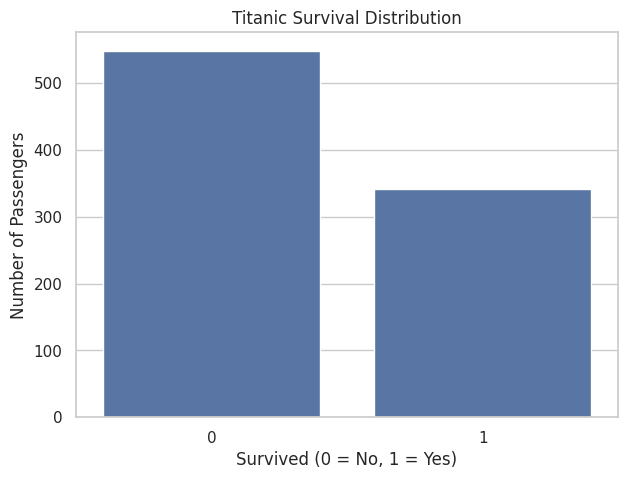

Survival Rate: 38.38%


In [50]:
# ============================================================
# CODE 6: Exploratory Data Analysis - Target Distribution
# ============================================================

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="survived")
plt.title("Titanic Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()

print("Survival Rate: {:.2f}%".format(y.mean() * 100))

survived,0,1
sex,,
female,25.80,74.20
male,81.11,18.89


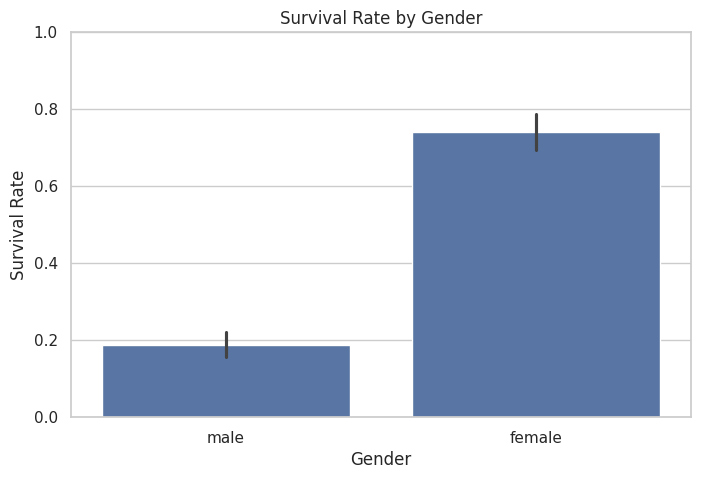

In [51]:
# ============================================================
# CODE 7: Survival by Gender
# ============================================================

gender_survival = pd.crosstab(df["sex"], df["survived"], normalize="index") * 100
display(gender_survival.round(2))

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="sex", y="survived")
plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()

survived,0,1
pclass,,
1,37.04,62.96
2,52.72,47.28
3,75.76,24.24


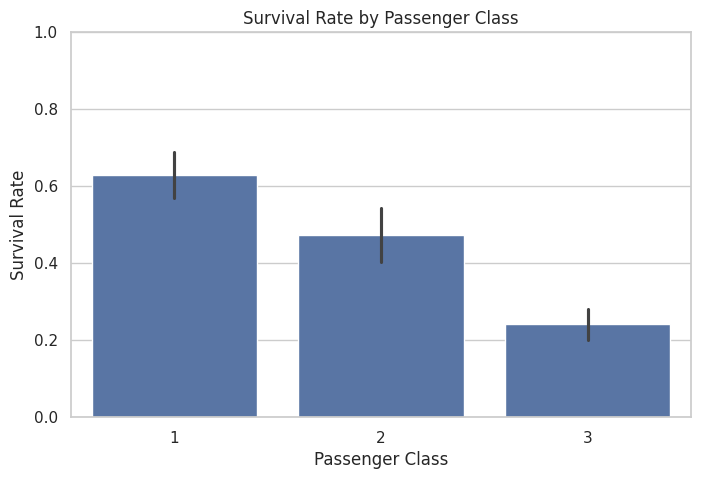

In [52]:
# ============================================================
# CODE 8: Survival by Passenger Class
# ============================================================

class_survival = pd.crosstab(df["pclass"], df["survived"], normalize="index") * 100
display(class_survival.round(2))

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="pclass", y="survived")
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()

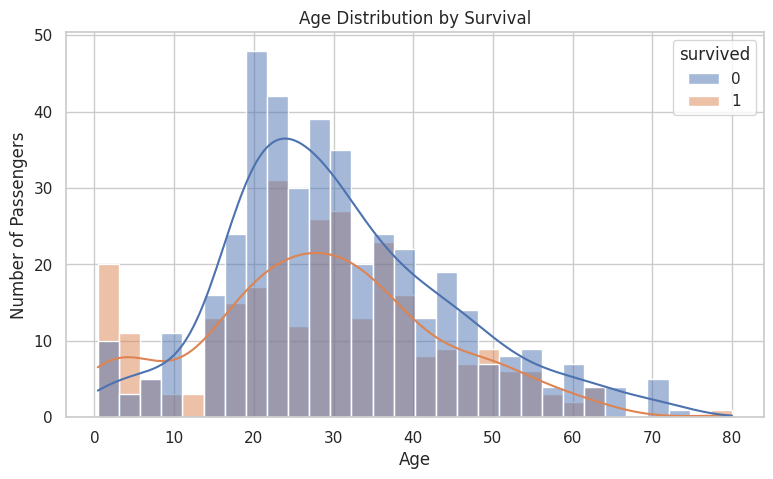

In [53]:
# ============================================================
# CODE 9: Age Distribution
# ============================================================

plt.figure(figsize=(9, 5))
sns.histplot(data=df, x="age", hue="survived", kde=True, bins=30)
plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

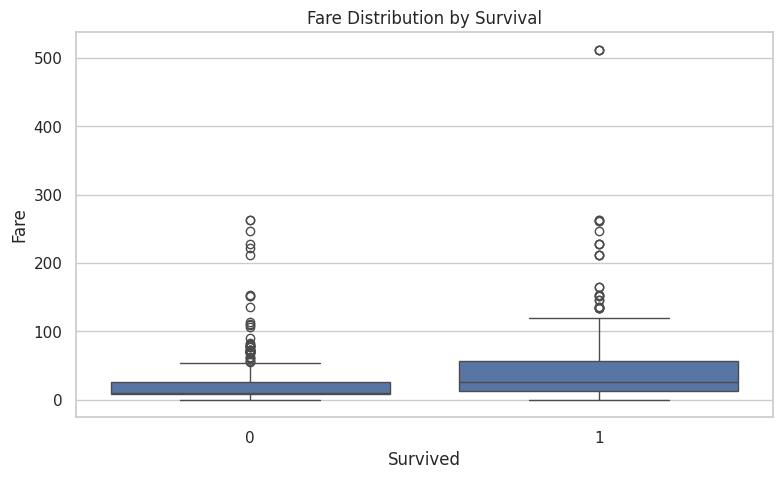

In [54]:
# ============================================================
# CODE 10: Fare Distribution
# ============================================================

plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="survived", y="fare")
plt.title("Fare Distribution by Survival")
plt.xlabel("Survived")
plt.ylabel("Fare")
plt.show()

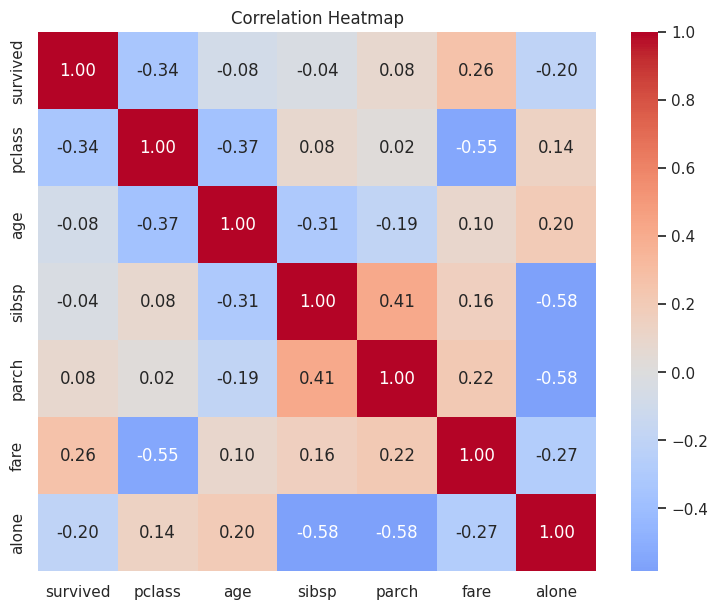

In [55]:
# ============================================================
# CODE 11: Correlation Analysis
# ============================================================

numeric_cols = ["survived", "pclass", "age", "sibsp", "parch", "fare", "alone"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

## 3. Key EDA Observations

From the exploratory analysis, we can investigate patterns such as:

- Survival rates differ considerably by gender.
- Passenger class is strongly associated with survival.
- Fare and passenger class provide useful predictive information.
- Age has a weaker but meaningful relationship with survival.
- Missing values exist in columns such as age and embarked, so preprocessing is required before machine learning.

These observations should be validated through the machine-learning models rather than treated as proof of causation.

In [56]:
# ============================================================
# CODE 12: Train/Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (712, 8)
Testing set : (179, 8)


In [57]:
# ============================================================
# CODE 13: Build Preprocessing Pipeline
# ============================================================

numeric_features = ["pclass", "age", "sibsp", "parch", "fare"]
categorical_features = ["sex", "embarked", "alone"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [58]:
# ============================================================
# CODE 14: Logistic Regression Model
# ============================================================

logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [59]:
# ============================================================
# CODE 15: Random Forest Model
# ============================================================

random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        random_state=42,
        class_weight="balanced"
    ))
])

random_forest_model.fit(X_train, y_train)

rf_pred = random_forest_model.predict(X_test)
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [60]:
# ============================================================
# CODE 16: Model Evaluation Function
# ============================================================

def evaluate_model(model_name, y_true, y_pred, y_prob):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

results = pd.DataFrame([
    evaluate_model("Logistic Regression", y_test, logistic_pred, logistic_prob),
    evaluate_model("Random Forest", y_test, rf_pred, rf_prob)
])

display(results.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8045,0.7833,0.6812,0.7287,0.8501
1,Random Forest,0.8045,0.7742,0.6957,0.7328,0.8395


In [61]:
# ============================================================
# CODE 17: Classification Report - Best Model
# ============================================================

best_model_name = results.sort_values("F1 Score", ascending=False).iloc[0]["Model"]

if best_model_name == "Random Forest":
    best_pred = rf_pred
    best_prob = rf_prob
    best_model = random_forest_model
else:
    best_pred = logistic_pred
    best_prob = logistic_prob
    best_model = logistic_model

print("Best model based on F1 Score:", best_model_name)
print("\nClassification Report:")
print(classification_report(y_test, best_pred))

Best model based on F1 Score: Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.87      0.85       110
           1       0.77      0.70      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



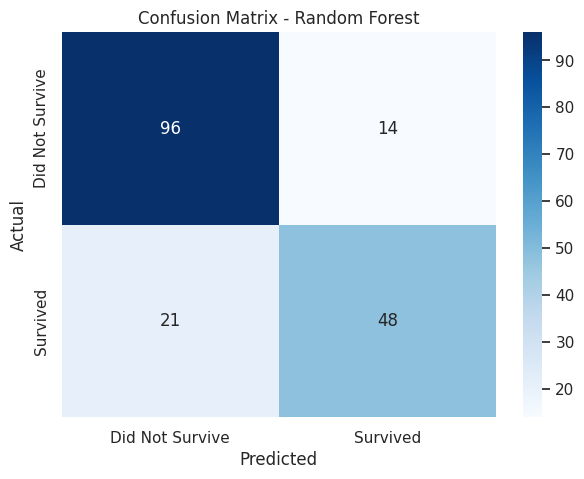

In [62]:
# ============================================================
# CODE 18: Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Did Not Survive", "Survived"],
    yticklabels=["Did Not Survive", "Survived"]
)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

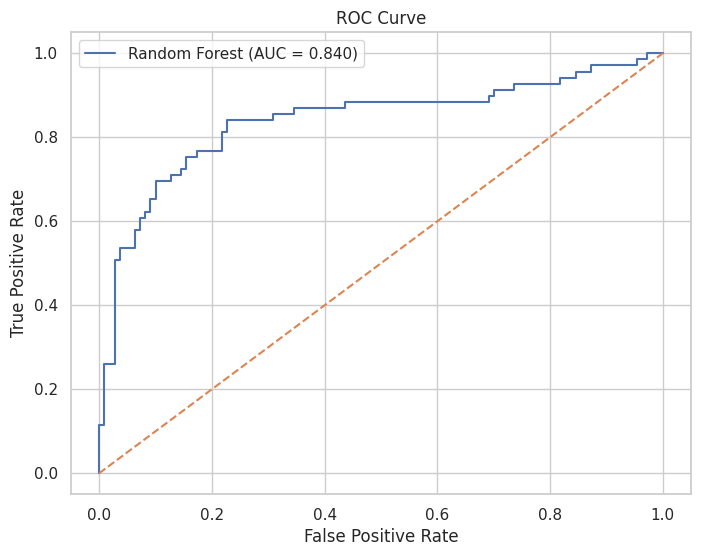

In [63]:
# ============================================================
# CODE 19: ROC Curve
# ============================================================

fpr, tpr, _ = roc_curve(y_test, best_prob)
auc_score = roc_auc_score(y_test, best_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"{best_model_name} (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

,Feature,Importance
4,num__fare,0.212416
5,cat__sex_female,0.203945
1,num__age,0.175437
6,cat__sex_male,0.166465
0,num__pclass,0.102160
2,num__sibsp,0.037868
3,num__parch,0.032780
9,cat__embarked_S,0.019293
10,cat__alone_False,0.014516
7,cat__embarked_C,0.014137


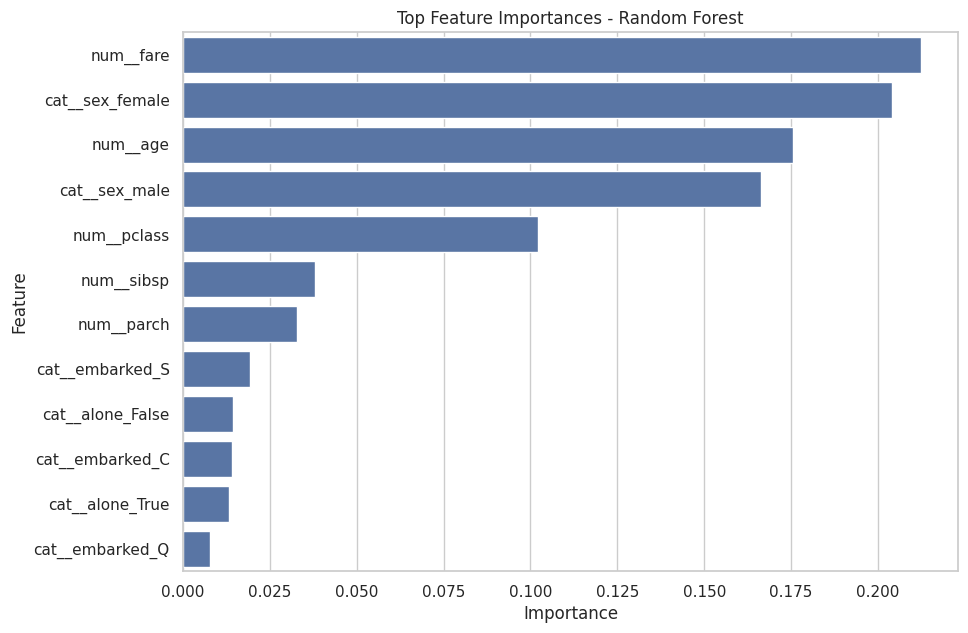

In [64]:
# ============================================================
# CODE 20: Feature Importance / Model Interpretation
# ============================================================

# Feature importance is available for Random Forest.
# If Logistic Regression is selected as best, we still display
# Random Forest feature importance as an additional interpretation.

rf_preprocessor = random_forest_model.named_steps["preprocessor"]
rf_classifier = random_forest_model.named_steps["classifier"]

feature_names = rf_preprocessor.get_feature_names_out()
importances = rf_classifier.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

display(feature_importance.head(15))

plt.figure(figsize=(10, 7))
sns.barplot(
    data=feature_importance.head(12),
    x="Importance",
    y="Feature"
)
plt.title("Top Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

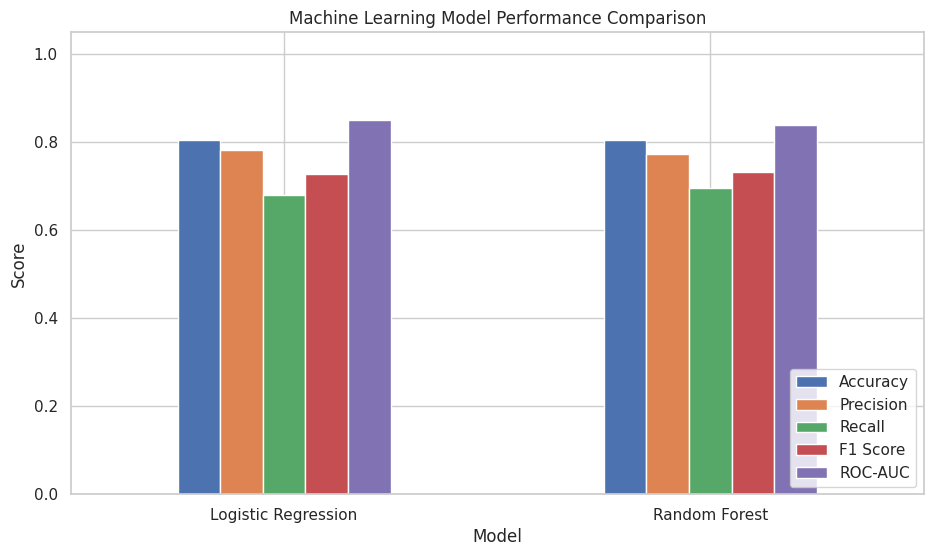

In [65]:
# ============================================================
# CODE 21: Model Comparison Visualization
# ============================================================

comparison = results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]]

comparison.plot(kind="bar", figsize=(11, 6))
plt.title("Machine Learning Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

## 4. Final Insights

### Data Insights
1. Passenger gender is an important variable associated with survival.
2. Passenger class is strongly related to survival outcomes.
3. Fare provides additional information about passenger travel class and is useful for prediction.
4. Age, family-related variables, and embarkation information contribute additional predictive signals.
5. Missing data must be handled carefully to avoid model errors and biased analysis.

### Machine Learning Insights
- Logistic Regression provides an interpretable baseline classification model.
- Random Forest can capture non-linear relationships between passenger characteristics.
- Accuracy alone should not be used as the only metric; precision, recall, F1-score and ROC-AUC provide a broader evaluation.
- The best model in this notebook is selected automatically using **F1 Score** on the test set.

> **Important:** Exact metric values may vary slightly depending on the dataset version and environment. Run all cells in Google Colab and use the generated values in your final report/post.

In [66]:
# ============================================================
# CODE 22: Final Project Summary
# ============================================================

best_row = results.sort_values("F1 Score", ascending=False).iloc[0]

print("=" * 60)
print("CODemax FINAL DATA SCIENCE PROJECT SUMMARY")
print("=" * 60)
print(f"Dataset              : Titanic")
print(f"Total records        : {len(df)}")
print(f"Number of features   : {len(features)}")
print(f"Best model           : {best_row['Model']}")
print(f"Accuracy             : {best_row['Accuracy']:.4f}")
print(f"Precision            : {best_row['Precision']:.4f}")
print(f"Recall               : {best_row['Recall']:.4f}")
print(f"F1 Score             : {best_row['F1 Score']:.4f}")
print(f"ROC-AUC              : {best_row['ROC-AUC']:.4f}")
print("=" * 60)

CODemax FINAL DATA SCIENCE PROJECT SUMMARY
Dataset              : Titanic
Total records        : 891
Number of features   : 8
Best model           : Random Forest
Accuracy             : 0.8045
Precision            : 0.7742
Recall               : 0.6957
F1 Score             : 0.7328
ROC-AUC              : 0.8395


## 5. Conclusion

This project demonstrates a complete Data Science workflow from raw data exploration to machine-learning prediction.

The Titanic dataset was analyzed using Python, Pandas, NumPy, Matplotlib and Seaborn. Missing values were handled through a preprocessing pipeline, categorical variables were encoded, numerical variables were scaled, and two classification algorithms—Logistic Regression and Random Forest—were trained and evaluated.

The project shows how exploratory analysis and machine learning can be combined to understand patterns and build predictive models. The final model selection is based on evaluation metrics rather than accuracy alone.

### Skills Demonstrated
- Python Programming
- Data Cleaning
- Exploratory Data Analysis
- Data Visualization
- Feature Engineering
- Data Preprocessing
- Classification
- Model Evaluation
- Scikit-learn Pipelines
- GitHub Portfolio Development

## 6. GitHub Submission Checklist

Before submitting to Codemax:

- [ ] Run every notebook cell from top to bottom.
- [ ] Confirm there are no errors.
- [ ] Save the executed `.ipynb` file.
- [ ] Add a professional `README.md`.
- [ ] Upload the notebook and README to GitHub.
- [ ] Make the repository public if Codemax requires a public repository.
- [ ] Copy the Google Colab link and enable appropriate sharing access.
- [ ] Publish the LinkedIn post.
- [ ] Submit all three links in Codemax Module 6.

**Suggested repository name:** `codemax-final-data-science-titanic`